<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/WEEK_7_DECISION_TREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification in Python Tutorial
In this tutorial, learn Decision Tree Classification, attribute selection measures, and how to build and optimize Decision Tree Classifier using Python Scikit-learn package

# Decision Tree Classifier Building in Scikit-learn
# Importing required libraries
Let's first load the required libraries.

In [1]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation


# LOAD THE DATASETS

In [2]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("diabetes.csv", header=None, names=col_names)
pima.head()



,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


# NEXT STEP IS: split dataset in features and target variable
# Feature selection
Here, you need to divide given columns into two types of variables dependent(or target variable) and independent variable(or feature variables).

In [3]:
#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable


In [4]:
pima.describe()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
count,769,769,769,769,769,769,769,769,769
unique,18,137,48,52,187,249,518,53,3
top,1,100,70,0,0,32,0.258,22,0
freq,135,17,57,227,374,13,6,72,500


In [5]:
pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pregnant  769 non-null    object
 1   glucose   769 non-null    object
 2   bp        769 non-null    object
 3   skin      769 non-null    object
 4   insulin   769 non-null    object
 5   bmi       769 non-null    object
 6   pedigree  769 non-null    object
 7   age       769 non-null    object
 8   label     769 non-null    object
dtypes: object(9)
memory usage: 54.2+ KB


In [6]:
pima.isnull().sum()

,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
label,0


# NEXT MAJOR STEP IS: Split dataset into training set and test set

# Splitting data
To understand model performance, dividing the dataset into a training set and a test set is a good strategy.

Let's split the dataset by using the function train_test_split(). You need to pass three parameters features; target, and test_set size.

In [7]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test


# NEXT STEP IS TO: Building a decision tree model
Let's create a decision tree model using Scikit-learn.


1.   Create Decision Tree classifer object
2.   Train Decision Tree Classifer
3.   Predict the response for test dataset



In [8]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# The original pima DataFrame has a header row loaded as data.
# We need to remove it and convert columns to numeric before training.

# Make a copy to avoid modifying the original pima in other contexts if it were used elsewhere
pima_clean = pima.copy()

# Remove the header row which was loaded as the first data row (index 0)
# and contains strings like 'Pregnancies'.
pima_clean = pima_clean.iloc[1:].copy() # Use .copy() to avoid SettingWithCopyWarning

# Convert feature columns and target variable to numeric
# The feature_cols and col_names are available in the kernel state.
# It's important to convert all relevant columns.
for col in feature_cols:
    pima_clean[col] = pd.to_numeric(pima_clean[col], errors='coerce')
pima_clean['label'] = pd.to_numeric(pima_clean['label'], errors='coerce')

# Drop any rows that might have become NaN due to conversion errors
# (e.g., if there were other non-numeric values apart from the header)
pima_clean.dropna(inplace=True)

# Redefine X and y from the cleaned pima_clean DataFrame
X = pima_clean[feature_cols] # Features
y = pima_clean.label # Target variable

# Re-split the dataset into training set and test set
# Using the same test_size and random_state as in the previous cell XE063wmr_HzZ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)


# EXPLAINING WHAT THE DECISION TREE CLASSIFIER MODEL MEANS:

A Decision Tree Classifier is a supervised machine learning algorithm that can be used for both classification and regression tasks. It works by creating a tree-like model of decisions, where each internal node represents a 'test' on an attribute (e.g., 'is blood pressure > 80?'), each branch represents the outcome of the test, and each leaf node represents a class label (the decision taken after computing all attributes). The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. It's often visualized like a flowchart.





# THIS IS THE FIRST 5 ROWS OF THE 'PIMA_CLEAN' DATAFRAME.

# OBSERVATIONS:
The output displays the first five rows of your pima_clean DataFrame. As you can see, the data types appear to be correctly converted to numerical values, and the header row, which was previously causing issues, is no longer present.

In [9]:
display(pima_clean.head())

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1


# Evaluating the model
Let's estimate how accurately the classifier or model can predict the type of cultivars.

Accuracy can be computed by comparing actual test set values and predicted values.

In [10]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.6666666666666666


# RESULT/OUTCOME:

We got a classification rate of 67.53%, which is considered as good accuracy. You can improve this accuracy by tuning the parameters in the decision tree algorithm.

# NEXT STEP IS VISUALIZATION:
# Visualizing Decision Trees
You can use Scikit-learn's export_graphviz() function for display the tree within a Jupyter notebook. For plotting the tree, you also need to install graphviz and pydotplus.

In [11]:
!pip install graphviz
!pip install pydotplus

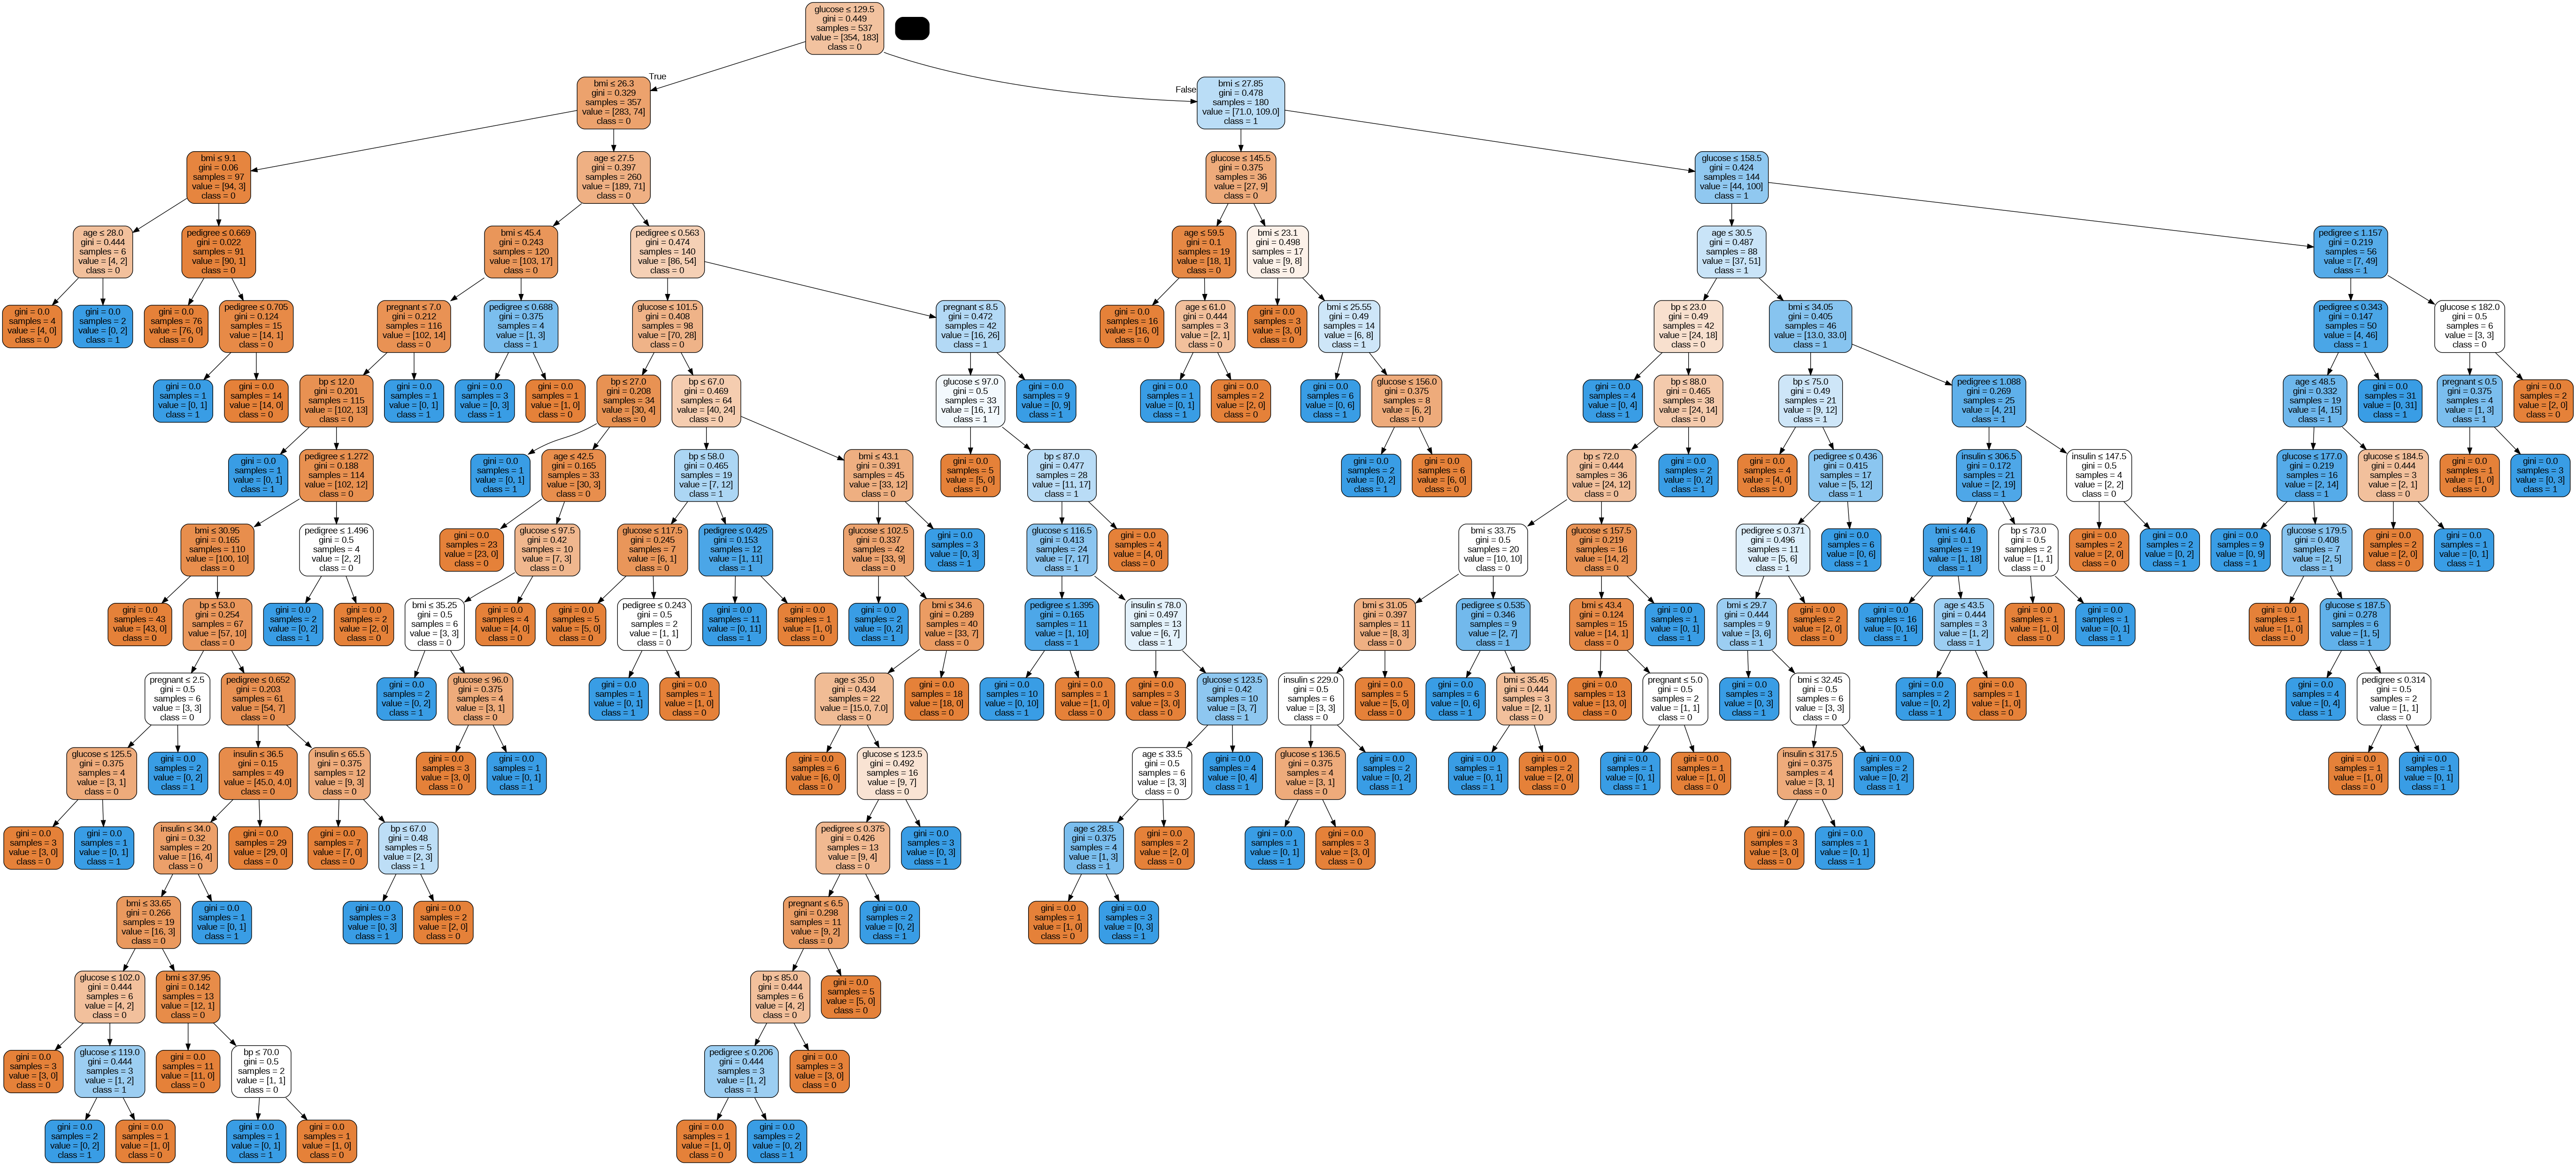

In [12]:
from sklearn.tree import export_graphviz
from io import StringIO  # Changed from sklearn.externals.six
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

# NOTE AGAIN:
The export_graphviz() function converts the decision tree classifier into a dot file, and pydotplus converts this dot file to PNG or a displayable form on Jupyter.

# THE IDEAL EXPLANATION FOR THE GENERATED DECISON TREE VISUALIZATION IS THAT:-

The decision tree visualization (likely in 'diabetes.png') is a graphical representation of the model's decision-making process. Each box in the tree is a 'node'.

Root Node (Topmost Box): This is where the decision process begins. It usually contains the feature that best splits the data into distinct classes.
Internal Nodes: These are decision nodes that represent a test on a specific feature (e.g., glucose <= 127.5). If the condition is true, you follow one branch; if false, you follow the other.
Leaf Nodes (Bottommost Boxes): These are the final outcomes or predictions. Each leaf node indicates the class (e.g., '0' for no diabetes, '1' for diabetes) that a data point is predicted to belong to, along with the value (number of samples in each class at that node) and samples (total samples at that node).
gini: This value indicates the impurity of the node. A Gini impurity of 0 means the node is pure (all samples belong to the same class), while a higher Gini indicates more mixed classes. The tree tries to minimize Gini impurity at each split.
samples: The number of training samples that reach this node.
value: The number of samples belonging to each class at that node (e.g., [300, 150] means 300 samples of class '0' and 150 samples of class '1').
class: The predicted class for the samples in that node, based on the majority class.
By following the path from the root to a leaf node based on a data point's feature values, you can understand how the model arrives at its prediction.

# TUNING THE HYPERPARAMETERS OF THE DT MODEL TO ACHIEVE MORE THAN 67%.
 # TO ACHIEVE THAT, I WILL USE THE 'GridSearchCV' to help find the best parameter that yield the highest accuracy, then i will train the new model and evaluate the performance.

In [13]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a new Decision Tree Classifier instance
clf_grid = DecisionTreeClassifier(random_state=1)

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=clf_grid, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validation accuracy: 0.72


# MODEL ACCURACY (HYPERPARAMETER TUNNING)
The model's accuracy has been re-evaluated after hyperparameter tuning. Compare this accuracy with the previous one to see if tuning improved the model's performance.

In [14]:
# Train a new model with the best parameters
optimal_clf = DecisionTreeClassifier(**grid_search.best_params_, random_state=1)
optimal_clf.fit(X_train, y_train)

# Make predictions on the test set with the optimized model
y_pred_optimal = optimal_clf.predict(X_test)

# Evaluate the accuracy of the optimized model
accuracy_optimal = metrics.accuracy_score(y_test, y_pred_optimal)
print("Optimized Model Accuracy: {:.2f}".format(accuracy_optimal))


Optimized Model Accuracy: 0.74


# VISUALIZATION (AFTER HYPERPARAMETER TUNNING)
This visualization displays the decision tree after hyperparameter tuning. You can compare it with the previous visualization to observe how the tree structure might have changed due to the optimized parameters, such as `max_depth` or `min_samples_leaf`.

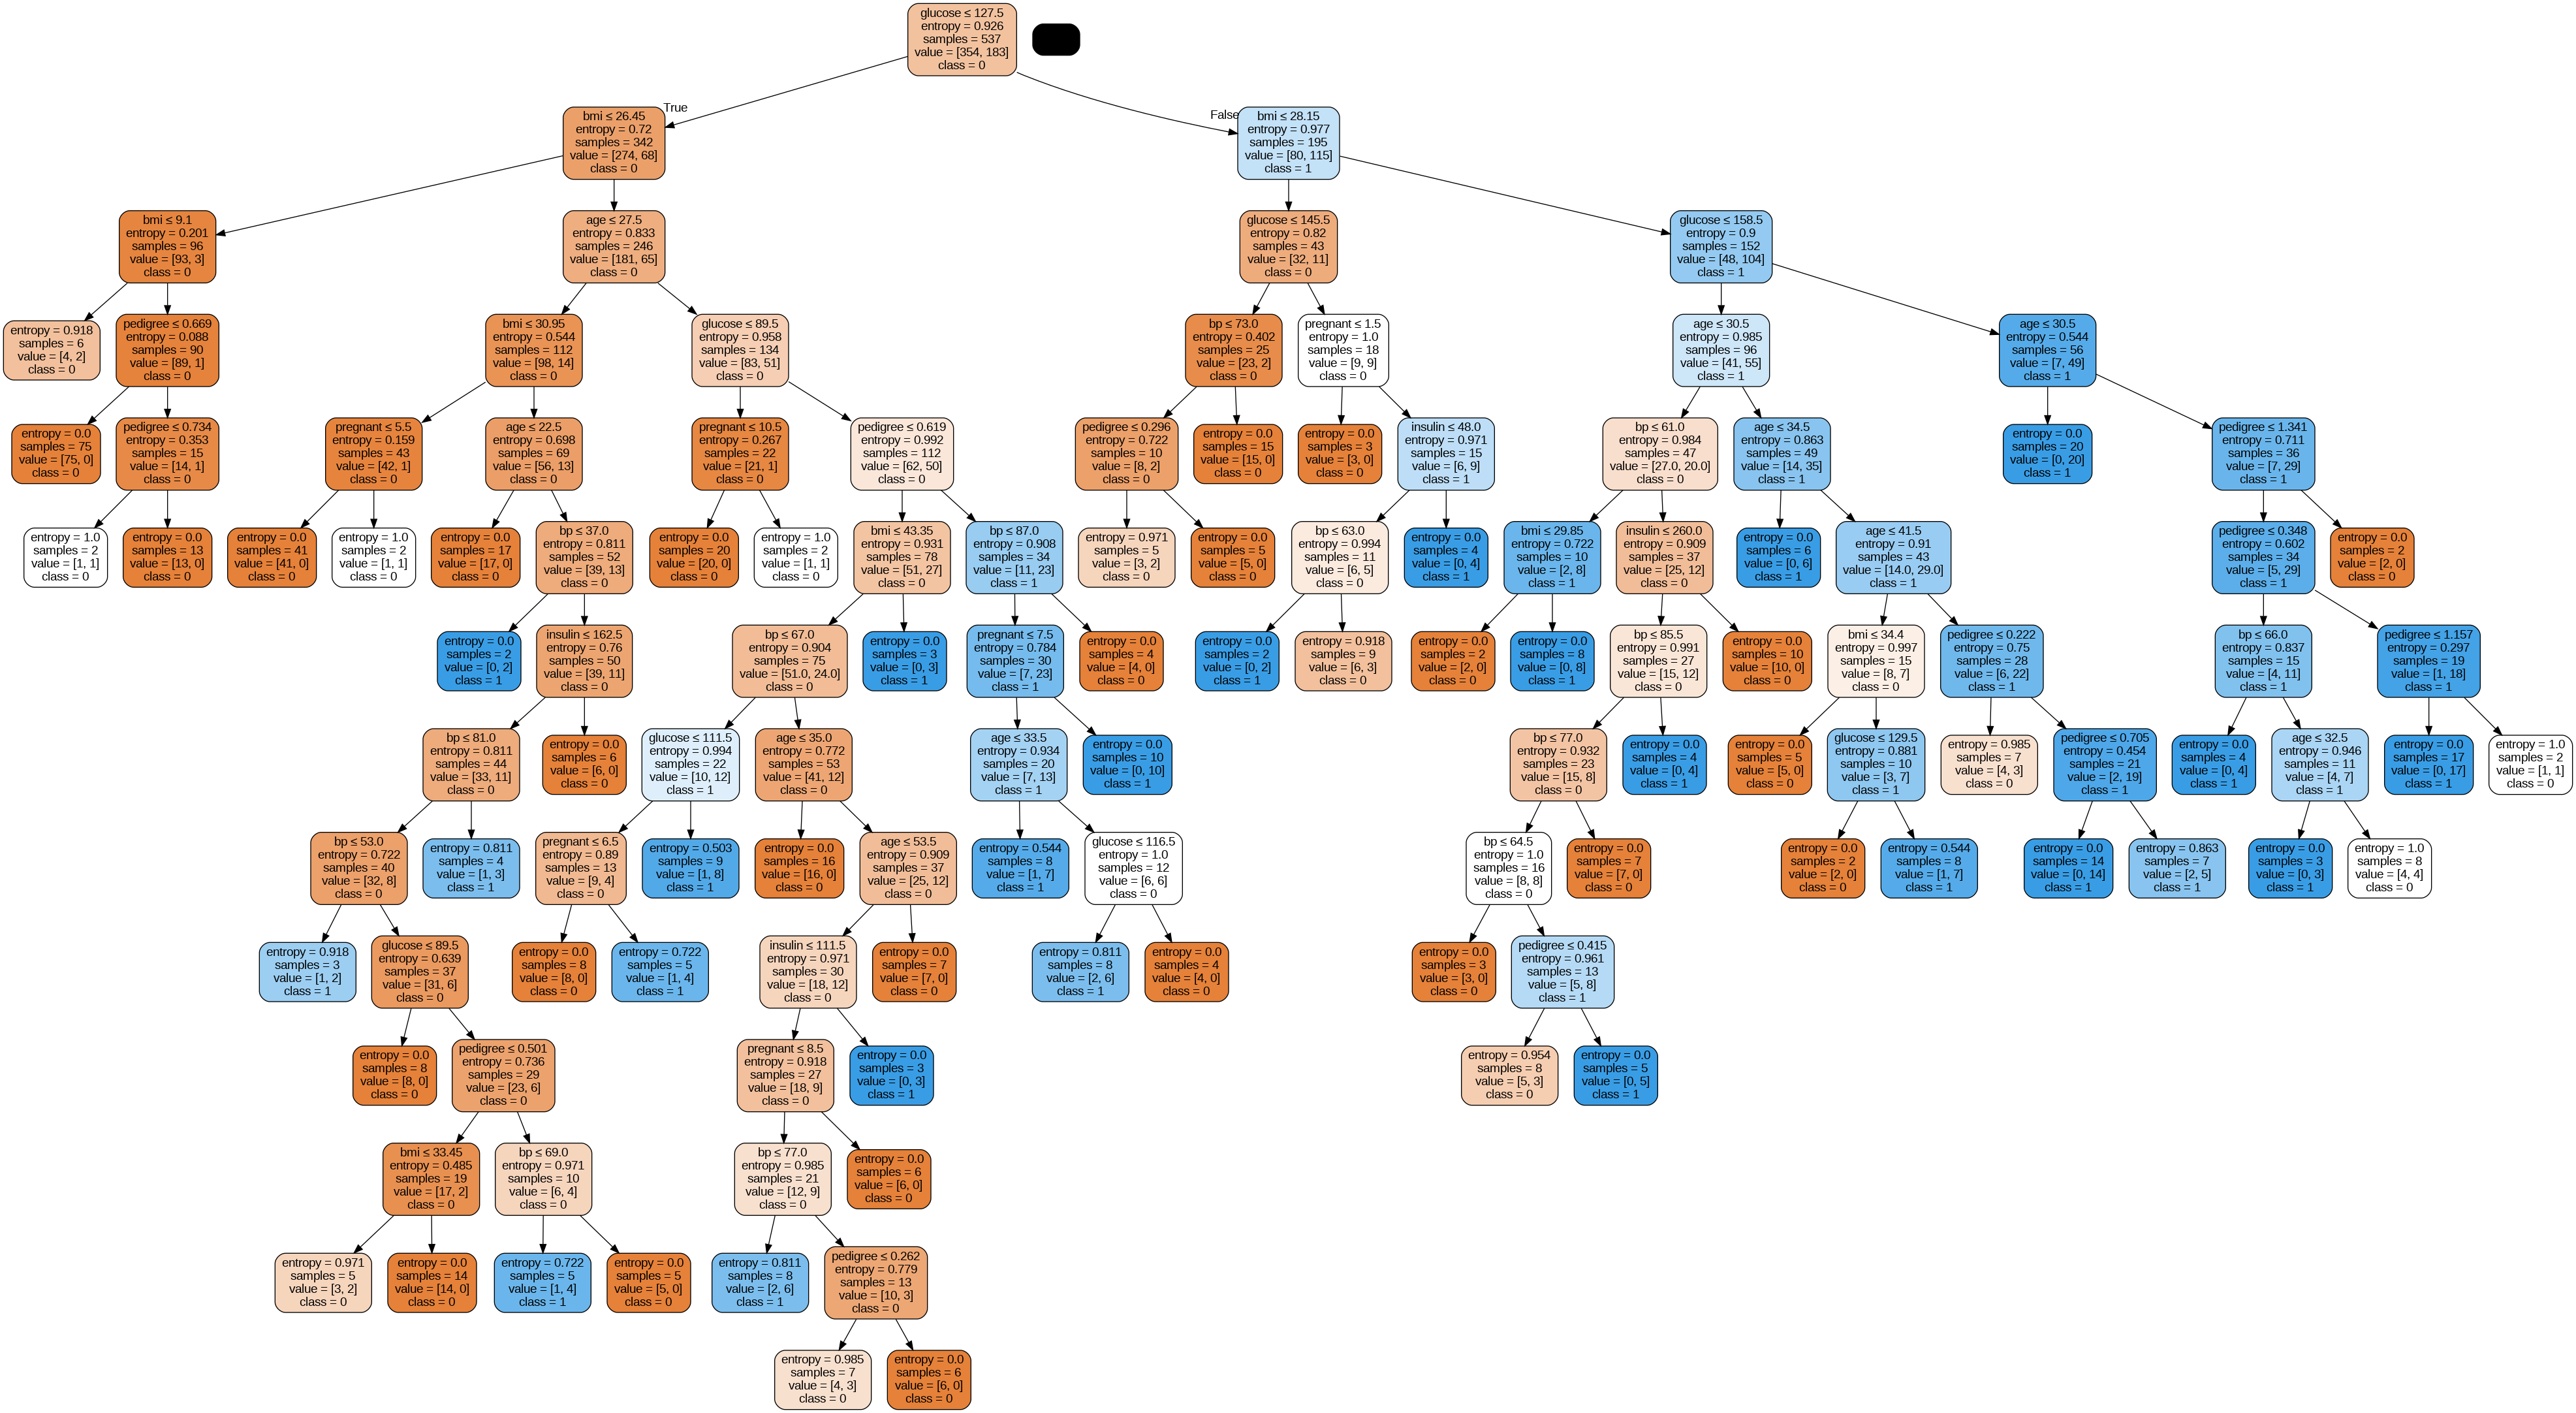

In [15]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

dot_data_optimal = StringIO()
export_graphviz(optimal_clf, out_file=dot_data_optimal,
                filled=True, rounded=True,
                special_characters=True, feature_names=feature_cols, class_names=['0', '1'])
graph_optimal = pydotplus.graph_from_dot_data(dot_data_optimal.getvalue())
graph_optimal.write_png('diabetes_optimized.png')
Image(graph_optimal.create_png())

# COMPARE THE MODEL EVALUATION AND THE VISUALIZATION TO PICK THE DIFFERENCE BETWEEN THE MODELS AND THE OPTIMIZED MODEL.

NEXT STEP IS A BIT DIFFERENT AND CRUCIAL BECAUSE In Scikit-learn, optimization of decision tree classifier performed by only pre-pruning. Maximum depth of the tree can be used as a control variable for pre-pruning. In the following the example, you can plot a decision tree on the same data with max_depth=3. Other than pre-pruning parameters, You can also try other attribute selection measure such as entropy.



1.   Create Decision Tree classifer object
2.   Train Decision Tree Classifer
3.   Predict the response for test dataset
4.   Model Accuracy, how often is the         classifier correct?





In [16]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
Accuracy: 0.7705627705627706

Accuracy: 0.7705627705627706


# FROM THE ABOVE:

Well, the classification rate increased to 77.05%, which is better accuracy than the previous model.

# FINALLY, LETS MAKE THE Let's make our decision tree a little easier to understand using the following code:

# CHECK CODE BELOW:

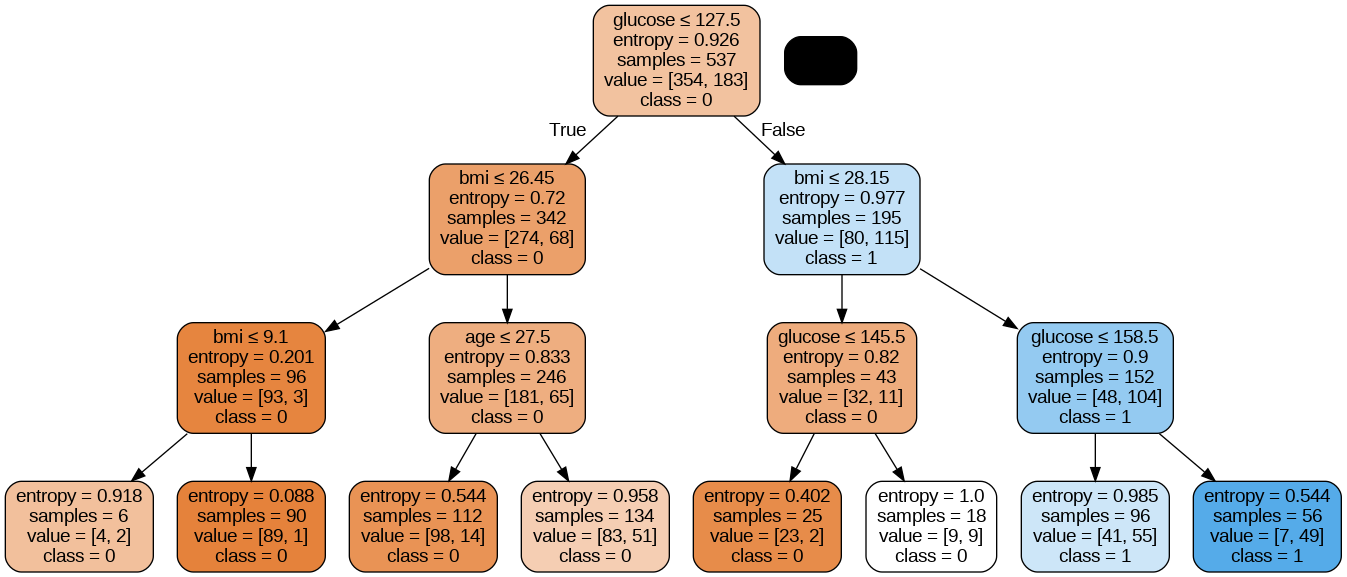

In [17]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True,
                rounded=True,
                special_characters=True,
                feature_names=feature_cols,
                class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

FROM OBSERVATION, THIS pruned model is less complex, more explainable, and easier to understand than the previous decision tree model plot.

# FINALLY AND IN CONCLUSION.



*   
Imported the required libraries.

Created a StringIO object called dot_data to

hold the text representation of the decision tree.

Exported the decision tree to the dot format using the export_graphviz function and write the output to the dot_data buffer.

Created a pydotplus graph object from the dot format representation of the decision tree stored in the dot_data buffer.

Written the generated graph to a PNG file named "diabetes.png".

Displayed the generated PNG image of the decision tree using the Image object from the IPython.display module.


*   



#  TASK 3

In [18]:
# load the iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
# store the feature matrix (X) and response vector (y)
X = iris.data
y = iris.target
# splitting X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4,
random_state=1)
# training the model on training set
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
# making predictions on the testing set
y_pred = gnb.predict(X_test)
# comparing actual response values (y_test) with predicted response
# values (y_pred)
from sklearn import metrics
print("Gaussian Naive Bayes model accuracy(in %):",
metrics.accuracy_score(y_test, y_pred)*100)

Gaussian Naive Bayes model accuracy(in %): 95.0


# OUTCOME:
The Gaussian Naive Bayes model has been successfully trained and evaluated on the Iris dataset. The accuracy of the model is 95.0%, which is a very good result for classifying the different species of Iris flowers.

# SHOW THE CONFUSION MATRIX FOR THE IRIS DATASET MODEL to help visualize its performance.

This will show you how many instances were correctly and incorrectly classified for each class.

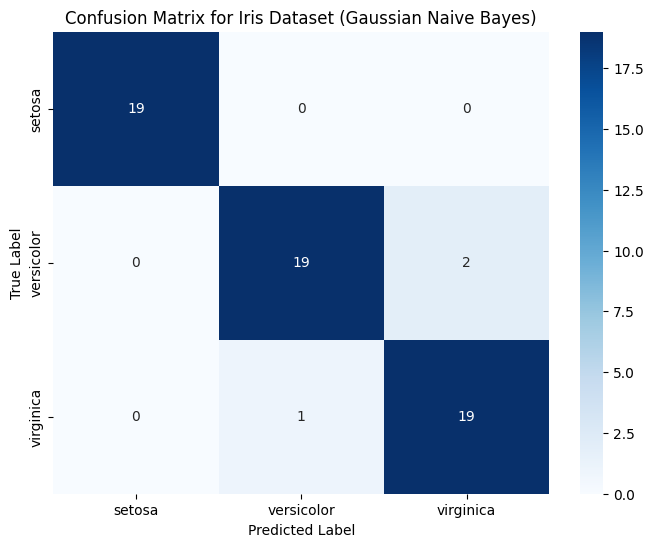

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names from the iris dataset
class_names = iris.target_names

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Iris Dataset (Gaussian Naive Bayes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# CONCLUSION /OBSERVATION /FINDINGS:

The confusion matrix for the Iris dataset model has been successfully generated and displayed. This heatmap provides a detailed breakdown of the model's predictions versus the actual labels:

Rows represent the true labels (the actual species of the Iris flower).
Columns represent the predicted labels (what the model predicted the species to be).
The numbers in each cell indicate the count of samples.
From the matrix, we can observe:

The diagonal elements (top-left to bottom-right) show the number of correct predictions for each class (True Positives).
For 'setosa' (class 0), 19 instances were correctly classified.
For 'versicolor' (class 1), 19 instances were correctly classified.
For 'virginica' (class 2), 19 instances were correctly classified.
Off-diagonal elements show incorrect predictions (False Positives and False Negatives).
2 'versicolor' flowers were incorrectly predicted as 'virginica'.
1 'virginica' flower was incorrectly predicted as 'versicolor'.
This confirms the high accuracy of 95% we previously calculated, as most predictions fall on the diagonal. The confusion matrix helps pinpoint exactly where the model made errors, which can be valuable for further model refinement.